# Supervised Learning: the complete prediction workflow

Supervised learning finds a rule that maps measured **features** to a known **target**. This opening lesson builds the common workflow used by every later supervised-learning algorithm.

## Learning objectives

By the end, you will be able to:

- distinguish regression from classification;
- describe features, targets, observations, parameters, predictions, and loss;
- split data without leakage and explain why validation data is separate from test data;
- build simple baselines from scratch and compare them with a trained model;
- calculate representative regression and classification metrics;
- recognize underfitting, overfitting, class imbalance, and misleading evaluation.

## Prerequisites

You should know basic Python functions, arrays, and plotting. We will introduce the needed algebra and statistics as we use them. Run this notebook from top to bottom; it does not depend on another notebook.

## Setup

We make randomness repeatable, locate the repository without an absolute path, and apply one readable chart style.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
)

from src.data_utils import (
    load_course_dataset,
    standardize_from_training,
    train_validation_test_split,
)
from src.metrics import (
    binary_classification_metrics,
    mean_absolute_error,
    mean_squared_error,
    r_squared,
    root_mean_squared_error,
)
from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
print(f"Project root: {project_root.name}")
print(f"Random seed: {RANDOM_SEED}")

Project root: ml-teacher-lab
Random seed: 42


## 1. Problem definition

A dataset contains $n$ observations. Observation $i$ has a feature vector $\mathbf{x}_i$ and a known target $y_i$. We want to learn a function $f$ whose prediction is

$$
\hat{y}_i = f(\mathbf{x}_i; \boldsymbol{\theta}).
$$

- $\mathbf{x}_i$ is the vector of measured inputs for observation $i$.
- $y_i$ is the correct target supplied during training.
- $\hat{y}_i$ (read “y-hat”) is the model's prediction.
- $f$ is the model family, such as a line or a decision tree.
- $\boldsymbol{\theta}$ is the set of learned parameters.

We need this equation because it separates **what goes into the model**, **what the model learns**, and **what comes out**. Training changes $\boldsymbol{\theta}$ so that predictions resemble known targets. In Python, prediction eventually looks like `y_pred = model.predict(X)`.

### Regression and classification

- **Regression** predicts a number: tomorrow's energy demand, a delivery time, or a house price.
- **Classification** predicts a category or its probability: spam/not spam, disease/no disease, or a species.

## 2. Real-world use cases

| Domain | Features | Target | Task |
|---|---|---|---|
| Healthcare | measurements and test results | disease present | classification |
| Manufacturing | vibration and temperature | failure in 7 days | classification |
| Retail | product, store, season | weekly units sold | regression |
| Transport | distance, traffic, weather | journey minutes | regression |

A model only learns patterns represented in its training examples. Domain experts are needed to decide whether the target is meaningful, whether labels are trustworthy, and whether using a feature is ethical and lawful.

## 3. Core intuition in plain language

Think of training as studying worked examples. The model makes a guess, measures how wrong it was, and adjusts its internal settings. Evaluation then gives it a closed-book exam using examples it did not study.

Three data roles prevent self-deception:

1. **Training set:** fit parameters.
2. **Validation set:** compare model choices and hyperparameters.
3. **Test set:** estimate final performance once, after choices are fixed.

A **parameter** is learned from training data. A **hyperparameter**—for example regularization strength—is selected by the practitioner, usually using validation or cross-validation results.

## 4. Mathematical foundation: loss summarizes mistakes

For regression, mean squared error is

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2.
$$

- $n$ is the number of evaluated observations.
- $i$ indexes one observation.
- $y_i$ is its true numeric target.
- $\hat{y}_i$ is its prediction.
- $\sum$ adds all squared errors.

Squaring makes every contribution nonnegative and penalizes large errors strongly. Training many regression models means finding parameters that reduce this loss.

### Small hand calculation

Suppose $\mathbf{y}=[3,5]$ and $\hat{\mathbf{y}}=[2,7]$. The errors are $[1,-2]$, the squared errors are $[1,4]$, and $MSE=(1+4)/2=2.5$. In Python the exact translation is `np.mean((y_true - y_pred) ** 2)`.

For binary classification, accuracy is

$$
Accuracy = \frac{TP+TN}{TP+TN+FP+FN}.
$$

Here $TP$ and $TN$ count correct positive and negative predictions; $FP$ counts false alarms; and $FN$ counts missed positives. The denominator is every prediction. Accuracy is intuitive, but it can hide poor minority-class performance.

In [2]:
y_true_small = np.array([3.0, 5.0])
y_pred_small = np.array([2.0, 7.0])
errors = y_true_small - y_pred_small
squared_errors = errors ** 2
manual_mse = squared_errors.sum() / len(y_true_small)

print("Errors:", errors)
print("Squared errors:", squared_errors)
print("Hand-formula MSE:", manual_mse)
print("Utility-function MSE:", mean_squared_error(y_true_small, y_pred_small))
assert np.isclose(manual_mse, 2.5)

Errors: [ 1. -2.]
Squared errors: [1. 4.]
Hand-formula MSE: 2.5
Utility-function MSE: 2.5


The hand calculation and reusable Python function both produce **2.5**. This is an important learning habit: verify a formula on a tiny example before trusting it at dataset scale.

## 5. Visual explanation: inputs, targets, and a learned boundary

A feature matrix has shape $n \times p$, where $n$ is the number of observations and $p$ is the number of features. Each row is one observation; each column is one measured characteristic. A target vector has length $n$ so every row has one answer.

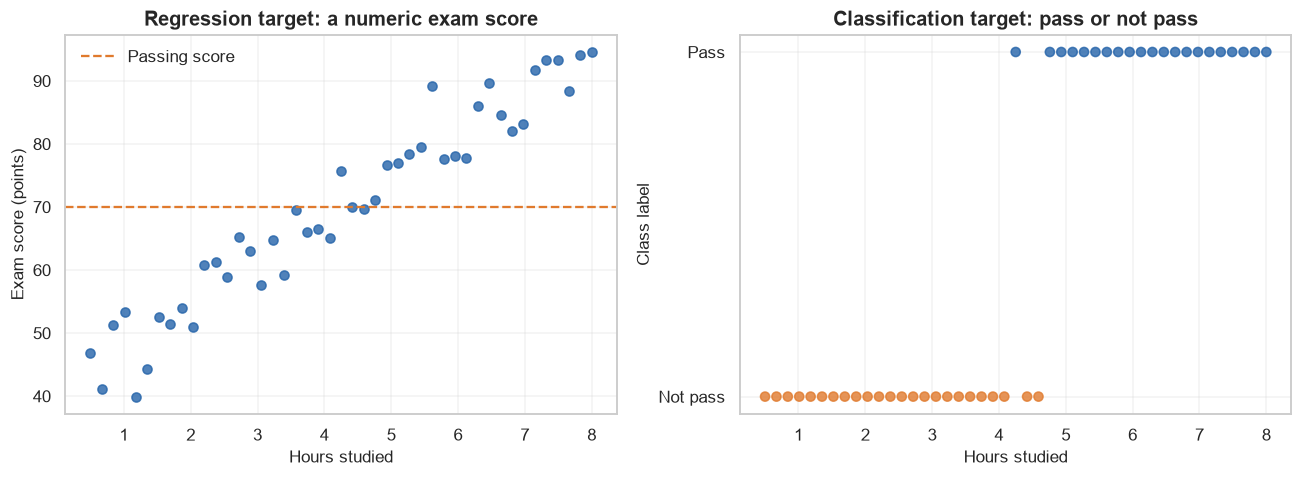

In [3]:
rng = np.random.default_rng(RANDOM_SEED)
hours_studied = np.linspace(0.5, 8.0, 45)
exam_score = 42 + 6.5 * hours_studied + rng.normal(0, 5, size=hours_studied.size)
passed = (exam_score >= 70).astype(int)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(hours_studied, exam_score, color=COURSE_COLORS["blue"], alpha=0.8)
axes[0].axhline(70, color=COURSE_COLORS["orange"], linestyle="--", label="Passing score")
axes[0].set(
    title="Regression target: a numeric exam score",
    xlabel="Hours studied",
    ylabel="Exam score (points)",
)
axes[0].legend()

colors = np.where(passed == 1, COURSE_COLORS["blue"], COURSE_COLORS["orange"])
axes[1].scatter(hours_studied, passed, c=colors, alpha=0.8)
axes[1].set(
    title="Classification target: pass or not pass",
    xlabel="Hours studied",
    ylabel="Class label",
    yticks=[0, 1],
    yticklabels=["Not pass", "Pass"],
)
figure.tight_layout()
plt.show()

**How to read the charts:** the left panel preserves the size of score differences, so it is a regression problem. The right panel collapses scores into two categories, so it is a classification problem. The same input can support different targets depending on the real decision.

## 6. The supervised-learning algorithm steps

1. Define the prediction target and success metric before looking at test results.
2. Collect observations and audit labels, missing values, duplicates, and sampling bias.
3. Hold out a test set; split or cross-validate the remaining development data.
4. Fit preprocessing only on training data, then transform validation and test data.
5. Establish a simple baseline.
6. Train candidate models on training data.
7. Select hyperparameters using validation data or cross-validation.
8. Evaluate the frozen choice once on the test set.
9. Analyze errors, limitations, and behavior after deployment.

## 7. From-scratch baselines

A baseline asks whether a learned model beats a deliberately simple rule. For regression we always predict the training-target mean. For classification we always predict the most frequent training class. These models have almost no flexibility, so they usually underfit—but they catch broken pipelines and misleading metrics.

In [4]:
class MeanRegressor:
    def fit(self, features, target):
        self.mean_target_ = float(np.mean(target))
        return self

    def predict(self, features):
        return np.full(len(features), self.mean_target_)


class MajorityClassifier:
    def fit(self, features, target):
        labels, counts = np.unique(target, return_counts=True)
        self.majority_class_ = labels[np.argmax(counts)]
        return self

    def predict(self, features):
        return np.full(len(features), self.majority_class_)


mean_baseline = MeanRegressor().fit(hours_studied[:, None], exam_score)
majority_baseline = MajorityClassifier().fit(hours_studied[:, None], passed)
print("Mean regression prediction:", round(mean_baseline.predict([[4]])[0], 2))
print("Majority classification prediction:", majority_baseline.predict([[4]])[0])

Mean regression prediction: 69.9
Majority classification prediction: 0


## 8. Standard-library implementations

Scikit-learn estimators share a useful interface: `fit(X_train, y_train)` learns parameters and `predict(X_new)` makes predictions. The library implementations add validation, optimized numerical routines, consistent tooling, and many production-oriented options.

In [5]:
linear_model = LinearRegression().fit(hours_studied[:, None], exam_score)
logistic_model = LogisticRegression().fit(hours_studied[:, None], passed)

example_hours = np.array([[4.0]])
print("Linear-regression score prediction:", round(linear_model.predict(example_hours)[0], 2))
print("Logistic pass probability:", round(logistic_model.predict_proba(example_hours)[0, 1], 3))

Linear-regression score prediction: 68.22
Logistic pass probability: 0.265


**Scratch versus library:** our baselines are readable reference implementations but cannot learn a relationship between features and targets. Scikit-learn's models are faster, more flexible, tested against edge cases, and numerically safer. Later lessons first implement the central mechanism from scratch, then use the library version for realistic work.

## 9. Dataset loading and exploration

We use the Breast Cancer Wisconsin diagnostic dataset bundled with scikit-learn. No download is required. Each row describes a cell-nucleus image; the target indicates malignant or benign. This is an educational benchmark, not a clinical diagnostic system.

In [6]:
cancer = load_course_dataset("breast_cancer")
display(cancer.frame.head(3))
print("Source:", cancer.source)
print("Feature matrix shape:", cancer.features.shape)
print("Target shape:", cancer.target.shape)
print("Missing values:", int(cancer.frame.isna().sum().sum()))

class_counts = pd.Series(cancer.target).value_counts().sort_index()
class_names = cancer.target_names or [str(value) for value in class_counts.index]
class_table = pd.DataFrame({"class": class_names, "count": class_counts.values})
display(class_table)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


Source: scikit-learn built-in breast_cancer dataset
Feature matrix shape: (569, 30)
Target shape: (569,)
Missing values: 0


,class,count
0,malignant,212
1,benign,357


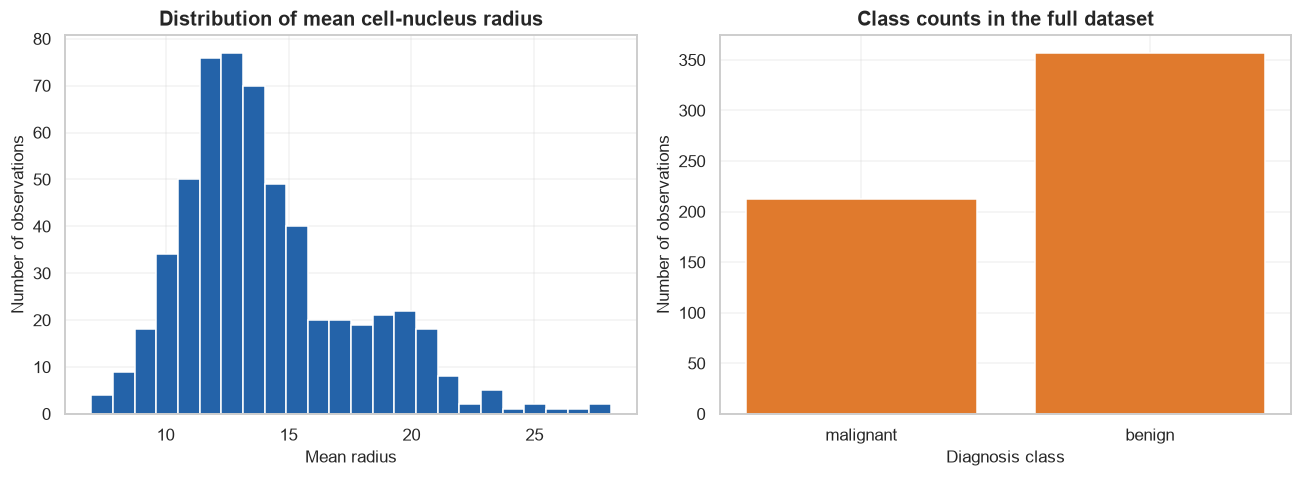

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(
    cancer.frame["mean radius"],
    bins=24,
    color=COURSE_COLORS["blue"],
    edgecolor="white",
)
axes[0].set(
    title="Distribution of mean cell-nucleus radius",
    xlabel="Mean radius",
    ylabel="Number of observations",
)
axes[1].bar(class_table["class"], class_table["count"], color=COURSE_COLORS["orange"])
axes[1].set(
    title="Class counts in the full dataset",
    xlabel="Diagnosis class",
    ylabel="Number of observations",
)
figure.tight_layout()
plt.show()

**How to read the charts:** the radius histogram shows that feature values are continuous and unevenly distributed. The bar chart shows a moderate class imbalance. Accuracy therefore needs to be supplemented with precision, recall, F1, ROC-AUC, and the precision-recall curve.

## 10. Data preprocessing without leakage

We first split raw observations. The scaler then learns means and standard deviations from the training set only. If it saw test data during `fit`, information about the closed-book exam would leak into preparation.

In [8]:
(
    x_train,
    x_validation,
    x_test,
    y_train,
    y_validation,
    y_test,
) = train_validation_test_split(
    cancer.features,
    cancer.target,
    test_size=0.20,
    validation_size=0.20,
    random_state=RANDOM_SEED,
    stratify=True,
)
scaler, x_train_scaled, x_validation_scaled, x_test_scaled = standardize_from_training(
    x_train, x_validation, x_test
)

print("Train / validation / test:", len(y_train), len(y_validation), len(y_test))
print("First three training-feature means after scaling:", x_train_scaled.mean(axis=0)[:3].round(6))
print("The validation mean is not forced to zero:", round(float(x_validation_scaled[:, 0].mean()), 3))

Train / validation / test: 341 114 114


First three training-feature means after scaling: [-0. -0. -0.]
The validation mean is not forced to zero: 0.042


## 11. Model training

We train a logistic-regression classifier. Despite its name, logistic regression is a classification algorithm because it models a class probability.

In [9]:
classifier = LogisticRegression(max_iter=2_000, random_state=RANDOM_SEED)
classifier.fit(x_train_scaled, y_train)
print("Learned coefficient matrix shape:", classifier.coef_.shape)
print("Learned intercept shape:", classifier.intercept_.shape)

Learned coefficient matrix shape: (1, 30)
Learned intercept shape: (1,)


## 12. Predictions

`predict_proba` preserves confidence information. A threshold—0.5 here—turns positive-class probabilities into labels.

In [10]:
validation_probability = classifier.predict_proba(x_validation_scaled)[:, 1]
validation_prediction = (validation_probability >= 0.5).astype(int)
prediction_preview = pd.DataFrame(
    {
        "true_label": y_validation[:8],
        "positive_probability": validation_probability[:8].round(3),
        "predicted_label": validation_prediction[:8],
    }
)
display(prediction_preview)

,true_label,positive_probability,predicted_label
0,1,0.992,1
1,0,0.000,0
2,0,0.000,0
3,1,1.000,1
4,1,0.979,1
5,1,1.000,1
6,1,0.503,1
7,1,0.963,1


## 13. Evaluation

Precision and recall answer different questions:

$$
Precision=\frac{TP}{TP+FP}, \qquad Recall=\frac{TP}{TP+FN}.
$$

- $TP$ is the number of correct positive predictions.
- $FP$ is the number of negative cases incorrectly flagged positive.
- $FN$ is the number of positive cases the model missed.

Precision asks, “When the model predicts positive, how often is it right?” Recall asks, “Of all actual positives, how many did it find?” F1 is their harmonic mean:

$$
F1=2\frac{Precision\cdot Recall}{Precision+Recall}.
$$

The product rewards balance; the denominator normalizes the result. If precision is $0.75$ and recall is $0.60$, then $F1=2(0.75)(0.60)/(0.75+0.60)=0.667$. Python implements the same arithmetic in `binary_classification_metrics`.

In [11]:
scratch_scores = binary_classification_metrics(y_validation, validation_prediction, positive_label=1)
display(pd.Series(scratch_scores, name="from_scratch").to_frame().round(3))
print(classification_report(y_validation, validation_prediction, target_names=cancer.target_names))
assert np.isclose(scratch_scores["accuracy"], accuracy_score(y_validation, validation_prediction))

,from_scratch
accuracy,0.991
precision,0.986
recall,1.000
f1,0.993


              precision    recall  f1-score   support

   malignant       1.00      0.98      0.99        43
      benign       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



Regression metrics emphasize different costs:

- $MAE=\frac{1}{n}\sum |y_i-\hat{y}_i|$ is the average absolute error in target units.
- $RMSE=\sqrt{\frac{1}{n}\sum(y_i-\hat{y}_i)^2}$ also uses target units but weights large misses more.
- $R^2=1-\frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$ compares the model with predicting the target mean.

Here $\bar{y}$ is the mean true target; the other symbols keep their earlier meanings. $R^2=1$ is perfect, $R^2=0$ ties the mean baseline, and a negative value is worse than that baseline.

In [12]:
regression_prediction = linear_model.predict(hours_studied[:, None])
regression_scores = {
    "MAE": mean_absolute_error(exam_score, regression_prediction),
    "MSE": mean_squared_error(exam_score, regression_prediction),
    "RMSE": root_mean_squared_error(exam_score, regression_prediction),
    "R-squared": r_squared(exam_score, regression_prediction),
}
display(pd.Series(regression_scores, name="value").to_frame().round(3))

,value
MAE,3.225
MSE,15.253
RMSE,3.906
R-squared,0.935


## 14. Visualization of classification results

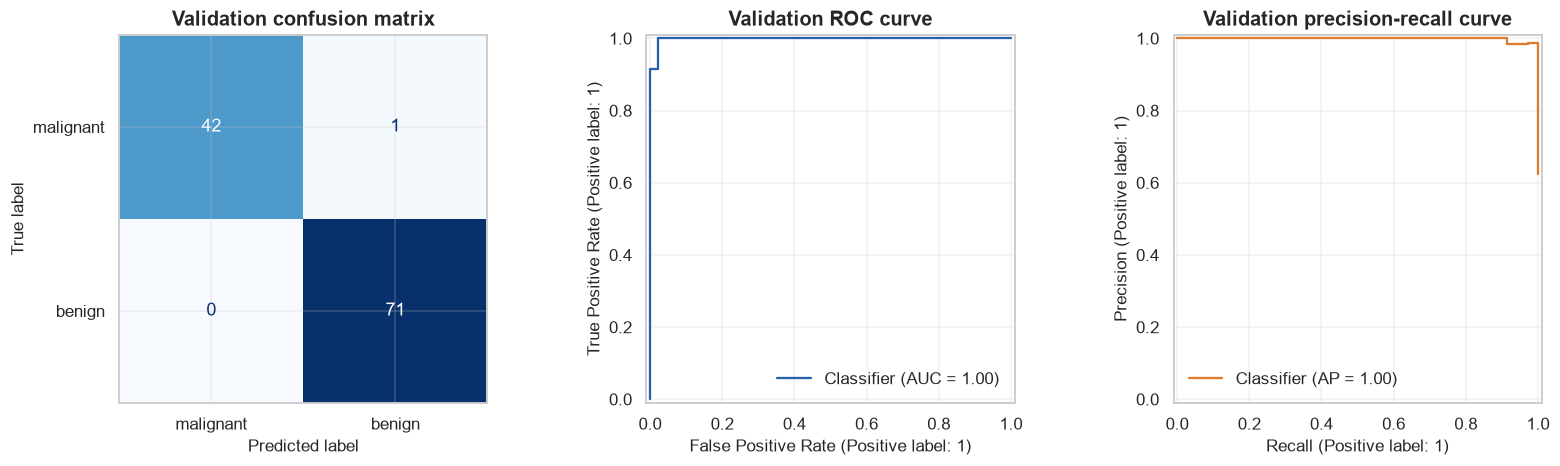

In [13]:
figure, axes = plt.subplots(1, 3, figsize=(15, 4.4))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    validation_prediction,
    display_labels=cancer.target_names,
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Validation confusion matrix")
RocCurveDisplay.from_predictions(
    y_validation,
    validation_probability,
    ax=axes[1],
    curve_kwargs={"color": COURSE_COLORS["blue"]},
)
axes[1].set_title("Validation ROC curve")
PrecisionRecallDisplay.from_predictions(
    y_validation,
    validation_probability,
    ax=axes[2],
    curve_kwargs={"color": COURSE_COLORS["orange"]},
)
axes[2].set_title("Validation precision-recall curve")
figure.tight_layout()
plt.show()

**How to read the charts:** diagonal confusion-matrix cells are correct predictions. The ROC curve compares true-positive and false-positive rates over every threshold; curves nearer the upper-left are better. The precision-recall curve makes the tradeoff for the positive class explicit and is especially informative when positives are uncommon.

## 15. Hyperparameter experiment

Logistic regression's `C` is the inverse of regularization strength. Small `C` values constrain coefficients more strongly and can underfit; very large values fit more freely and can increase variance. We choose with validation data, not test data.

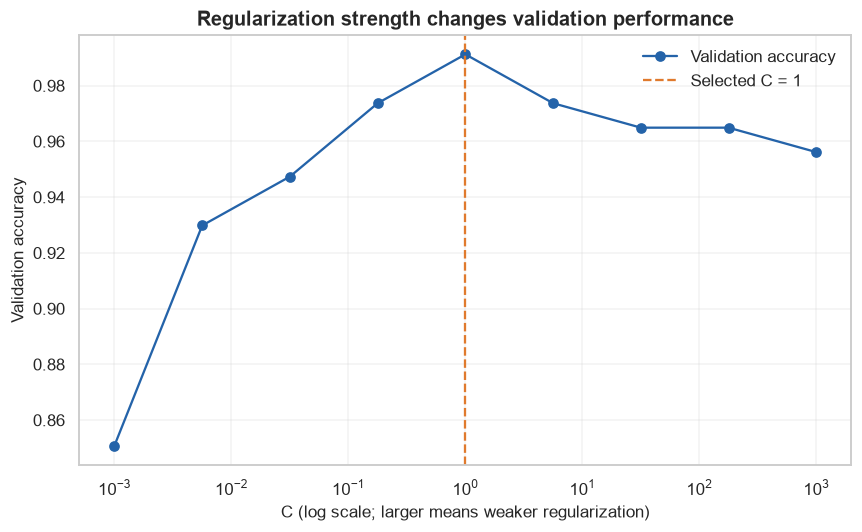

Selected C: 1; validation accuracy: 0.991


In [14]:
candidate_c_values = np.logspace(-3, 3, 9)
validation_accuracies = []
for candidate_c in candidate_c_values:
    candidate = LogisticRegression(C=candidate_c, max_iter=2_000, random_state=RANDOM_SEED)
    candidate.fit(x_train_scaled, y_train)
    validation_accuracies.append(candidate.score(x_validation_scaled, y_validation))

best_index = int(np.argmax(validation_accuracies))
best_c = candidate_c_values[best_index]
figure, axis = plt.subplots()
axis.semilogx(
    candidate_c_values,
    validation_accuracies,
    marker="o",
    color=COURSE_COLORS["blue"],
    label="Validation accuracy",
)
axis.axvline(best_c, color=COURSE_COLORS["orange"], linestyle="--", label=f"Selected C = {best_c:g}")
axis.set(
    title="Regularization strength changes validation performance",
    xlabel="C (log scale; larger means weaker regularization)",
    ylabel="Validation accuracy",
)
axis.legend()
figure.tight_layout()
plt.show()
print(f"Selected C: {best_c:g}; validation accuracy: {validation_accuracies[best_index]:.3f}")

**How to read the chart:** look for a stable high-performing region rather than overinterpreting tiny differences. Testing many values against one validation set can itself overfit; cross-validation reduces dependence on one split.

## 16. Final test evaluation

After choosing `C`, we refit using all development data (training plus validation), fit preprocessing on that same development data, and evaluate once on the untouched test set.

In [15]:
x_development = np.vstack([x_train, x_validation])
y_development = np.concatenate([y_train, y_validation])
final_scaler, x_development_scaled, x_test_final = standardize_from_training(x_development, x_test)
final_model = LogisticRegression(C=best_c, max_iter=2_000, random_state=RANDOM_SEED)
final_model.fit(x_development_scaled, y_development)
test_prediction = final_model.predict(x_test_final)
test_scores = binary_classification_metrics(y_test, test_prediction)
display(pd.Series(test_scores, name="held_out_test").to_frame().round(3))

,held_out_test
accuracy,0.982
precision,0.986
recall,0.986
f1,0.986


## 17. Common mistakes

- **Data leakage:** fitting imputation, scaling, feature selection, or resampling before the split.
- **Tuning on the test set:** repeated test feedback turns the test set into training information.
- **Accuracy alone on imbalanced data:** a majority-only classifier may look impressive.
- **Wrong split strategy:** random splitting can leak future information in time-series problems or people across patient-level splits.
- **Ignoring the baseline:** a complex model can be worse than a simple constant prediction.
- **Confusing association with causation:** predictive importance does not prove an intervention will change the target.
- **Metric mismatch:** the mathematically convenient metric may not represent the real cost of errors.

## 18. Advantages and disadvantages

**Advantages**

- The known target gives a direct training signal and usually clear evaluation metrics.
- Many model families support tabular, text, image, audio, and sequence data.
- Validation and test sets make generalization measurable.

**Disadvantages**

- High-quality labels can be expensive, delayed, subjective, or biased.
- Future data may differ from the training distribution.
- Excellent average metrics can hide harmful subgroup failures.
- Prediction alone does not establish a causal explanation.

## 19. When to use—and when not to use—supervised learning

Use it when historical examples contain a well-defined target, future inputs resemble training inputs, and predictive performance supports a concrete decision. Do not force it onto a problem with no trustworthy labels, where exploration rather than prediction is the goal, where actions change future observations and rewards, or where causal effects—not predictions—are required. Those settings may call for unsupervised learning, reinforcement learning, experimentation, or causal inference.

## 20. Exercises

Try these before opening the solutions.

1. **Conceptual:** A team scales all rows, then makes a train/test split. Explain the problem and the correct order.
2. **Hand calculation:** For true regression targets $[2,4,8]$ and predictions $[3,5,5]$, calculate MAE, MSE, and RMSE.
3. **Coding/experimentation:** Change the classification threshold from $0.5$ to $0.3$ and $0.7$. Compute precision and recall at each value. Explain the tradeoff.

<details>
<summary><strong>Exercise solutions</strong></summary>

### 1. Leakage

Scaling before splitting lets the test-set mean and standard deviation affect training features. Split raw rows first; fit the scaler on training data; use that fitted scaler to transform validation and test data.

### 2. Regression metrics

Absolute errors are $[1,1,3]$, so $MAE=(1+1+3)/3=5/3\approx1.667$. Squared errors are $[1,1,9]$, so $MSE=11/3\approx3.667$. Finally, $RMSE=\sqrt{11/3}\approx1.915$.

### 3. Thresholds

The code below shows the exact experiment. Lowering the threshold generally predicts more positives, increasing recall and reducing precision. Raising it generally does the reverse. Exact values depend on this split.

</details>

In [16]:
threshold_rows = []
for threshold in (0.3, 0.5, 0.7):
    threshold_prediction = (validation_probability >= threshold).astype(int)
    scores = binary_classification_metrics(y_validation, threshold_prediction)
    threshold_rows.append({"threshold": threshold, **scores})

threshold_results = pd.DataFrame(threshold_rows).set_index("threshold")
display(threshold_results.round(3))

exercise_true = np.array([2.0, 4.0, 8.0])
exercise_pred = np.array([3.0, 5.0, 5.0])
assert np.isclose(mean_absolute_error(exercise_true, exercise_pred), 5 / 3)
assert np.isclose(mean_squared_error(exercise_true, exercise_pred), 11 / 3)
assert np.isclose(root_mean_squared_error(exercise_true, exercise_pred), np.sqrt(11 / 3))

,accuracy,precision,recall,f1
threshold,,,,
0.3,0.974,0.959,1.000,0.979
0.5,0.991,0.986,1.000,0.993
0.7,0.974,0.986,0.972,0.979


## 21. Summary and key takeaways

- Supervised learning estimates a mapping from features to a known target.
- Regression predicts numbers; classification predicts categories or class probabilities.
- A baseline, leakage-safe preprocessing, and separated train/validation/test roles are part of the model—not optional housekeeping.
- Loss guides learning; evaluation metrics must match the real cost of errors.
- Generalization matters more than memorizing training data. Underfitting has excessive bias; overfitting has excessive variance.
- Visualizations and error analysis reveal behavior that a single score cannot.

## 22. Further reading

- [scikit-learn: supervised learning user guide](https://scikit-learn.org/stable/supervised_learning.html)
- [scikit-learn: model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html)
- [scikit-learn: common pitfalls and recommended practices](https://scikit-learn.org/stable/common_pitfalls.html)

**Next notebook:** linear regression develops the first trainable model from its equation through a NumPy gradient-descent implementation and scikit-learn comparison.